In [1]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import (
    col,
    year,
    month,
    dayofmonth,
    round,
    sum as spark_sum,
    count,
    to_date
)

In [2]:
from pyspark.sql import SparkSession

spark = (
    SparkSession.builder
    .appName("EcommerceETL")
    .master("yarn")
    .enableHiveSupport()
    .getOrCreate()
)

print(spark.sparkContext.master)

2026-09-07 03:43:19,162 WARN util.Utils: Your hostname, localhost.localdomain resolves to a loopback address: 127.0.0.1; using 10.0.2.15 instead (on interface enp0s3)
2026-09-07 03:43:19,162 WARN util.Utils: Set SPARK_LOCAL_IP if you need to bind to another address
2026-09-07 03:43:19,519 WARN util.NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
2026-09-07 03:43:21,335 WARN yarn.Client: Neither spark.yarn.jars nor spark.yarn.archive is set, falling back to uploading libraries under SPARK_HOME.


yarn


In [3]:
RAW_PATH = "hdfs:///staging_zone/ecommerce/"
HIVE_DB = "ecommerce_dw_test"

In [4]:
spark.sql(f"""
CREATE DATABASE IF NOT EXISTS {HIVE_DB}
""")

spark.sql("SHOW DATABASES").show()

2026-09-07 03:44:30,746 WARN conf.HiveConf: HiveConf of name hive.stats.jdbc.timeout does not exist
2026-09-07 03:44:30,746 WARN conf.HiveConf: HiveConf of name hive.stats.retries.wait does not exist
2026-09-07 03:44:32,380 WARN metastore.ObjectStore: Failed to get database global_temp, returning NoSuchObjectException
2026-09-07 03:44:32,387 WARN metastore.ObjectStore: Failed to get database ecommerce_dw_test, returning NoSuchObjectException


+-----------------+
|        namespace|
+-----------------+
|          default|
|ecommerce_dw_test|
|        retail_db|
|     samsung_test|
+-----------------+



In [86]:
customers = (
    spark.read
    .format("avro")
    .load(f"{RAW_PATH}/customers")
)

customers.printSchema()
customers.show(5)

root
 |-- customer_id: string (nullable = true)
 |-- first_name: string (nullable = true)
 |-- last_name: string (nullable = true)
 |-- email: string (nullable = true)
 |-- country: string (nullable = true)
 |-- city: string (nullable = true)
 |-- signup_date: string (nullable = true)

+-----------+----------+---------+--------------------+------------+-------------+-------------+
|customer_id|first_name|last_name|               email|     country|         city|  signup_date|
+-----------+----------+---------+--------------------+------------+-------------+-------------+
|      90001|   Stephen|    Welch|stephen.welch9000...|Saudi Arabia|  Samanthaton|1755907200000|
|      90002|   Derrick|    Villa|derrick.villa9000...|       Qatar|    New David|1695945600000|
|      90003|      Juan|Robertson|juan.robertson900...|         UAE| Jacksonmouth|1641859200000|
|      90004|    Nicole|Hernandez|nicole.hernandez9...|      Kuwait|Port Kurtside|1728604800000|
|      90005|    Nathan|   Peters|

In [8]:
# customers = (
#     spark.read
#     .option("header", "false")
#     .option("inferSchema", "true")
#     .option("sep", ",")
#     .csv(f"{RAW_PATH}/customers")
# )

# customers = customers.toDF(
#     "customer_id",
#     "first_name",
#     "last_name",
#     "email",
#     "country",
#     "city",
#     "signup_date"
# )

# customers.printSchema()
# customers.show(5)

In [23]:
products = (
    spark.read
    .format("avro")
    .load(f"{RAW_PATH}/products")
)

products.printSchema()
products.show(5)

root
 |-- product_id: string (nullable = true)
 |-- product_name: string (nullable = true)
 |-- category: string (nullable = true)
 |-- price: decimal(10,2) (nullable = true)
 |-- stock_quantity: integer (nullable = true)

+----------+--------------------+---------+-------+--------------+
|product_id|        product_name| category|  price|stock_quantity|
+----------+--------------------+---------+-------+--------------+
|         1|Exclusive composi...|   Gaming|1978.97|           927|
|         2|Mandatory dedicat...|Furniture|1511.46|           122|
|         3|Secured radical s...|   Gaming|1542.36|            40|
|         4|Re-contextualized...|   Beauty|1647.17|           578|
|         5|Total foreground ...|   Sports|1024.78|           195|
+----------+--------------------+---------+-------+--------------+
only showing top 5 rows



In [24]:
# products = (
#     spark.read
#     .option("header", "false")
#     .option("inferSchema", "true")
#     .option("sep", ",")
#     .csv(f"{RAW_PATH}/products")
# )

# products = products.toDF(
#     "product_id",
#     "product_name",
#     "category",
#     "price",
#     "stock_quantity"
# )

# products.printSchema()
# products.show(5)

In [53]:
orders = (
    spark.read
    .format("avro")
    .load(f"{RAW_PATH}/orders")
)

orders.printSchema()
orders.show(5)

root
 |-- order_id: string (nullable = true)
 |-- customer_id: string (nullable = true)
 |-- order_date: string (nullable = true)
 |-- status: string (nullable = true)
 |-- shipping_country: string (nullable = true)

+--------+-----------+-------------+---------+----------------+
|order_id|customer_id|   order_date|   status|shipping_country|
+--------+-----------+-------------+---------+----------------+
|  290001|      35598|1730270732000|  pending|             UAE|
|  290002|      43295|1756813950000|  pending|          Kuwait|
|  290003|      22819|1752208660000|completed|          Jordan|
|  290004|      38887|1775486570000|completed|    Saudi Arabia|
|  290005|      45282|1749476990000|cancelled|           Qatar|
+--------+-----------+-------------+---------+----------------+
only showing top 5 rows



In [26]:
# orders = (
#     spark.read
#     .option("header", "false")
#     .option("inferSchema", "true")
#     .option("sep", ",")
#     .csv(f"{RAW_PATH}/orders")
# )

# orders = orders.toDF(
#     "order_id",
#     "customer_id",
#     "order_date",
#     "status",
#     "shipping_country"
# )

# orders.printSchema()
# orders.show(5)

In [27]:
order_items = (
    spark.read
    .format("avro")
    .load(f"{RAW_PATH}/order_items")
)

order_items.printSchema()
order_items.show(5)

root
 |-- order_item_id: string (nullable = true)
 |-- order_id: string (nullable = true)
 |-- product_id: string (nullable = true)
 |-- quantity: integer (nullable = true)
 |-- unit_price: decimal(10,2) (nullable = true)

+-------------+--------+----------+--------+----------+
|order_item_id|order_id|product_id|quantity|unit_price|
+-------------+--------+----------+--------+----------+
|      1990001|  347626|      7008|       1|   1289.14|
|      1990002|   82704|     19722|       1|    348.96|
|      1990003|  273492|      3714|       2|   1088.12|
|      1990004|  110082|      9241|       4|    431.53|
|      1990005|  192387|     17972|       2|     88.82|
+-------------+--------+----------+--------+----------+
only showing top 5 rows



In [28]:
# order_items = (
#     spark.read
#     .option("header", "false")
#     .option("inferSchema", "true")
#     .option("sep", ",")
#     .csv(f"{RAW_PATH}/order_items")
# )

# order_items = order_items.toDF(
#     "order_item_id",
#     "order_id",
#     "product_id",
#     "quantity",
#     "unit_price"
# )

# order_items.printSchema()
# order_items.show(5)

In [38]:
payments = (
    spark.read
    .format("avro")
    .load(f"{RAW_PATH}/payments")
)

payments.printSchema()
payments.show(5)

root
 |-- payment_id: string (nullable = true)
 |-- order_id: string (nullable = true)
 |-- payment_method: string (nullable = true)
 |-- payment_status: string (nullable = true)
 |-- payment_date: string (nullable = true)
 |-- amount: decimal(10,2) (nullable = true)

+----------+--------+--------------+--------------+-------------+-------+
|payment_id|order_id|payment_method|payment_status| payment_date| amount|
+----------+--------+--------------+--------------+-------------+-------+
|    280001|  280001|          cash|        failed|1779224996000|4833.68|
|    280002|  280002| bank_transfer|          paid|1726337610000|3378.63|
|    280003|  280003| bank_transfer|          paid|1755193694000|4367.58|
|    280004|  280004| bank_transfer|      refunded|1758169336000|2916.80|
|    280005|  280005|        paypal|          paid|1726872813000|4377.23|
+----------+--------+--------------+--------------+-------------+-------+
only showing top 5 rows



In [36]:
# payments = (
#     spark.read
#     .option("header", "false")
#     .option("inferSchema", "true")
#     .option("sep", ",")
#     .csv(f"{RAW_PATH}/payments")
# )

# payments = payments.toDF(
#     "payment_id",
#     "order_id",
#     "payment_method",
#     "payment_status",
#     "payment_date",
#     "amount"
# )

# payments.printSchema()
# payments.show(5)

In [37]:
customers = customers.dropDuplicates(["customer_id"])

products = products.dropDuplicates(["product_id"])

orders = orders.dropDuplicates(["order_id"])

order_items = order_items.dropDuplicates(["order_item_id"])

payments = payments.dropDuplicates(["payment_id"])

In [87]:
print("Customers:", customers.count())
print("Products:", products.count())
print("Orders:", orders.count())
print("Order Items:", order_items.count())
print("Payments:", payments.count())

Customers: 20000


Products: 10000
Orders: 20000
Order Items: 100000
Payments: 20000


2026-09-07 05:47:49,150 WARN spark.HeartbeatReceiver: Removing executor 2 with no recent heartbeats: 872333 ms exceeds timeout 120000 ms
2026-09-07 05:47:49,156 ERROR client.TransportClient: Failed to send RPC RPC 8872166208768431197 to /10.0.2.15:36772: java.nio.channels.ClosedChannelException
java.nio.channels.ClosedChannelException
	at io.netty.channel.AbstractChannel$AbstractUnsafe.newClosedChannelException(AbstractChannel.java:957)
	at io.netty.channel.AbstractChannel$AbstractUnsafe.write(AbstractChannel.java:865)
	at io.netty.channel.DefaultChannelPipeline$HeadContext.write(DefaultChannelPipeline.java:1367)
	at io.netty.channel.AbstractChannelHandlerContext.invokeWrite0(AbstractChannelHandlerContext.java:717)
	at io.netty.channel.AbstractChannelHandlerContext.invokeWriteAndFlush(AbstractChannelHandlerContext.java:764)
	at io.netty.channel.AbstractChannelHandlerContext$WriteTask.run(AbstractChannelHandlerContext.java:1071)
	at io.netty.util.concurrent.AbstractEventExecutor.safeExe

In [41]:
order_items = order_items.withColumn(
    "sales_amount",
    round(
        col("quantity") * col("unit_price"),
        2
    )
)

order_items.show(5)

+-------------+--------+----------+--------+----------+------------+
|order_item_id|order_id|product_id|quantity|unit_price|sales_amount|
+-------------+--------+----------+--------+----------+------------+
|        10096|  409756|      1753|       5|    127.10|      635.50|
|        10351|  436872|     13831|       4|    455.24|     1820.96|
|        10436|   63498|     19618|       4|   1552.85|     6211.40|
|        11078|  166424|     16988|       5|    819.04|     4095.20|
|      1110932|  349579|      4858|       1|    697.80|      697.80|
+-------------+--------+----------+--------+----------+------------+
only showing top 5 rows



In [42]:
# orders = orders.withColumn(
#     "order_date",
#     to_date("order_date", "yyyy-MM-dd HH:mm:ss")
# )

In [54]:
from pyspark.sql.functions import col

orders = orders.withColumn(
    "order_date",
    (col("order_date") / 1000).cast("timestamp")
)

orders.printSchema()
orders.show(5, truncate=False)

root
 |-- order_id: string (nullable = true)
 |-- customer_id: string (nullable = true)
 |-- order_date: timestamp (nullable = true)
 |-- status: string (nullable = true)
 |-- shipping_country: string (nullable = true)

+--------+-----------+-------------------+---------+----------------+
|order_id|customer_id|order_date         |status   |shipping_country|
+--------+-----------+-------------------+---------+----------------+
|290001  |35598      |2024-10-30 15:45:32|pending  |UAE             |
|290002  |43295      |2025-09-02 20:52:30|pending  |Kuwait          |
|290003  |22819      |2025-07-11 13:37:40|completed|Jordan          |
|290004  |38887      |2026-04-06 23:42:50|completed|Saudi Arabia    |
|290005  |45282      |2025-06-09 22:49:50|cancelled|Qatar           |
+--------+-----------+-------------------+---------+----------------+
only showing top 5 rows



In [55]:
orders.printSchema()

root
 |-- order_id: string (nullable = true)
 |-- customer_id: string (nullable = true)
 |-- order_date: timestamp (nullable = true)
 |-- status: string (nullable = true)
 |-- shipping_country: string (nullable = true)



In [56]:
orders.show(5)

+--------+-----------+-------------------+---------+----------------+
|order_id|customer_id|         order_date|   status|shipping_country|
+--------+-----------+-------------------+---------+----------------+
|  290001|      35598|2024-10-30 15:45:32|  pending|             UAE|
|  290002|      43295|2025-09-02 20:52:30|  pending|          Kuwait|
|  290003|      22819|2025-07-11 13:37:40|completed|          Jordan|
|  290004|      38887|2026-04-06 23:42:50|completed|    Saudi Arabia|
|  290005|      45282|2025-06-09 22:49:50|cancelled|           Qatar|
+--------+-----------+-------------------+---------+----------------+
only showing top 5 rows



In [46]:
# from pyspark.sql.functions import to_date

# orders = orders.withColumn(
#     "order_date",
#     to_date("order_date", "yyyy-MM-dd HH:mm:ss.S")
# )

In [62]:
from pyspark.sql.functions import to_date, substring

orders = orders.withColumn(
    "order_date",
    to_date(substring("order_date", 1, 10), "yyyy-MM-dd")
)

In [63]:
orders.printSchema()

root
 |-- order_id: string (nullable = true)
 |-- customer_id: string (nullable = true)
 |-- order_date: date (nullable = true)
 |-- status: string (nullable = true)
 |-- shipping_country: string (nullable = true)
 |-- year: integer (nullable = true)
 |-- month: integer (nullable = true)
 |-- day: integer (nullable = true)



In [64]:
orders.show(5)

+--------+-----------+----------+---------+----------------+----+-----+---+
|order_id|customer_id|order_date|   status|shipping_country|year|month|day|
+--------+-----------+----------+---------+----------------+----+-----+---+
|  290001|      35598|2024-10-30|  pending|             UAE|2024|   10| 30|
|  290002|      43295|2025-09-02|  pending|          Kuwait|2025|    9|  2|
|  290003|      22819|2025-07-11|completed|          Jordan|2025|    7| 11|
|  290004|      38887|2026-04-06|completed|    Saudi Arabia|2026|    4|  6|
|  290005|      45282|2025-06-09|cancelled|           Qatar|2025|    6|  9|
+--------+-----------+----------+---------+----------------+----+-----+---+
only showing top 5 rows



In [65]:
orders = (
    orders
    .withColumn("year", year("order_date"))
    .withColumn("month", month("order_date"))
    .withColumn("day", dayofmonth("order_date"))
)

orders.show(5)

+--------+-----------+----------+---------+----------------+----+-----+---+
|order_id|customer_id|order_date|   status|shipping_country|year|month|day|
+--------+-----------+----------+---------+----------------+----+-----+---+
|  290001|      35598|2024-10-30|  pending|             UAE|2024|   10| 30|
|  290002|      43295|2025-09-02|  pending|          Kuwait|2025|    9|  2|
|  290003|      22819|2025-07-11|completed|          Jordan|2025|    7| 11|
|  290004|      38887|2026-04-06|completed|    Saudi Arabia|2026|    4|  6|
|  290005|      45282|2025-06-09|cancelled|           Qatar|2025|    6|  9|
+--------+-----------+----------+---------+----------------+----+-----+---+
only showing top 5 rows



In [69]:
fact_sales = (
    order_items
    .join(
        orders,
        "order_id",
        "inner"
    )
    .join(
        products,
        "product_id",
        "inner"
    )
    .select(
        "order_item_id",
        "order_id",
        "customer_id",
        "product_id",
        "quantity",
        "unit_price",
        "sales_amount",
        "order_date",
        "status",
        "category",
        "year",
        "month",
        "day"
    )
)

In [70]:
fact_sales.printSchema()
fact_sales.show(10)

root
 |-- order_item_id: string (nullable = true)
 |-- order_id: string (nullable = true)
 |-- customer_id: string (nullable = true)
 |-- product_id: string (nullable = true)
 |-- quantity: integer (nullable = true)
 |-- unit_price: decimal(10,2) (nullable = true)
 |-- sales_amount: decimal(21,2) (nullable = true)
 |-- order_date: date (nullable = true)
 |-- status: string (nullable = true)
 |-- category: string (nullable = true)
 |-- year: integer (nullable = true)
 |-- month: integer (nullable = true)
 |-- day: integer (nullable = true)



+-------------+--------+-----------+----------+--------+----------+------------+----------+---------+-----------+----+-----+---+
|order_item_id|order_id|customer_id|product_id|quantity|unit_price|sales_amount|order_date|   status|   category|year|month|day|
+-------------+--------+-----------+----------+--------+----------+------------+----------+---------+-----------+----+-----+---+
|        14838|  480040|      49674|      1112|       1|    477.92|      477.92|2026-06-27|  pending|Accessories|2026|    6| 27|
|      1485193|  481551|      32511|      9051|       5|   1600.24|     8001.20|2025-03-27|completed|      Books|2025|    3| 27|
|      1640022|  290941|      10749|      6328|       1|   1564.50|     1564.50|2025-09-14|  shipped|      Shoes|2025|    9| 14|
|        16504|  298071|      95415|      2984|       2|   1503.47|     3006.94|2025-03-01|completed|     Sports|2025|    3|  1|
|        18992|  294919|      40883|       233|       1|     29.28|       29.28|2026-08-21|comple

In [74]:
dim_customer = customers.select(
    "customer_id",
    "first_name",
    "last_name",
    "email",
    "country",
    "city",
    "signup_date"
)

In [75]:
dim_product = products.select(
    "product_id",
    "product_name",
    "category",
    "price",
    "stock_quantity"
)

In [76]:
daily_sales = (
    fact_sales
    .groupBy(
        "year",
        "month",
        "day"
    )
    .agg(
        round(spark_sum("sales_amount"), 2).alias("total_Sales"),
        spark_sum("quantity").alias("total_quantity"),
        count("order_id").alias("total_items")
    )
)

In [77]:
daily_sales.orderBy(
    "year",
    "month",
    "day"
).show(20)

+----+-----+---+-----------+--------------+-----------+
|year|month|day|total_Sales|total_quantity|total_items|
+----+-----+---+-----------+--------------+-----------+
|2024|    9|  7|     859.64|             8|          3|
|2024|    9|  8|   19391.76|            18|          6|
|2024|    9|  9|    5830.78|             6|          2|
|2024|    9| 10|    9295.00|            11|          5|
|2024|    9| 11|    6006.68|            12|          3|
|2024|    9| 12|   17924.57|            18|          6|
|2024|    9| 13|   11390.54|            16|          6|
|2024|    9| 14|    6163.55|             9|          4|
|2024|    9| 15|    4290.98|             6|          2|
|2024|    9| 16|    7856.44|             5|          2|
|2024|    9| 18|    1966.71|             1|          1|
|2024|    9| 19|   13052.63|            11|          3|
|2024|    9| 20|   20553.95|            17|          4|
|2024|    9| 21|    3340.41|             4|          2|
|2024|    9| 22|   12953.79|            16|     

In [91]:
spark.sql(f"DROP TABLE IF EXISTS {HIVE_DB}.fact_sales")
spark.sql(f"DROP TABLE IF EXISTS {HIVE_DB}.dim_product")

fact_sales.write \
    .mode("overwrite") \
    .format("orc") \
    .partitionBy("year", "month") \
    .saveAsTable(f"{HIVE_DB}.fact_sales")

dim_product.write \
    .mode("overwrite") \
    .format("orc") \
    .saveAsTable(f"{HIVE_DB}.dim_product")

In [82]:
dim_customer.write \
    .mode("overwrite") \
    .format("parquet") \
    .option("compression", "snappy") \
    .saveAsTable(
        f"{HIVE_DB}.dim_customer"
    )

In [85]:
daily_sales.write \
    .mode("overwrite") \
    .format("parquet") \
    .option("compression", "snappy") \
    .saveAsTable(
        f"{HIVE_DB}.daily_sales"
    )

In [93]:
!pip install matplotlib seaborn


Defaulting to user installation because normal site-packages is not writeable
     |████████████████████████████████| 9.2 MB 2.6 MB/s eta 0:00:01
     |████████████████████████████████| 294 kB 3.2 MB/s eta 0:00:01
     |████████████████████████████████| 301 kB 2.7 MB/s eta 0:00:01
     |████████████████████████████████| 4.4 MB 3.6 MB/s eta 0:00:01
     |████████████████████████████████| 4.7 MB 1.3 MB/s eta 0:00:01
     |████████████████████████████████| 1.2 MB 1.8 MB/s eta 0:00:01
You should consider upgrading via the '/usr/local/bin/python3.8 -m pip install --upgrade pip' command.


/tmp/ipykernel_27567/1282446858.py:14: FutureWarning:                           

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


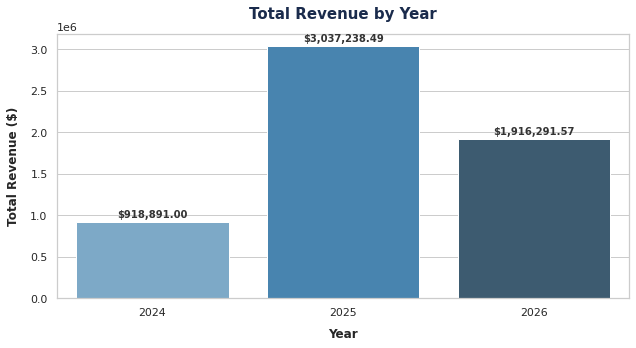

In [95]:
import matplotlib.pyplot as plt
import seaborn as sns

revenue_by_year = spark.sql(f"""
    SELECT year, SUM(total_sales) AS total_revenue
    FROM {HIVE_DB}.daily_sales
    GROUP BY year
    ORDER BY year
""").toPandas()

plt.figure(figsize=(9, 5))
sns.set_theme(style="whitegrid")

ax = sns.barplot(
    x="year", 
    y="total_revenue", 
    data=revenue_by_year, 
    palette="Blues_d"
)

plt.title("Total Revenue by Year", fontsize=15, fontweight='bold', pad=15, color='#1A2B4C')
plt.xlabel("Year", fontsize=12, fontweight='bold', labelpad=10)
plt.ylabel("Total Revenue ($)", fontsize=12, fontweight='bold', labelpad=10)

for p in ax.patches:
    height = p.get_height()
    ax.annotate(
        f"${height:,.2f}",
        (p.get_x() + p.get_width() / 2., height),
        ha='center', va='center',
        xytext=(0, 8),
        textcoords='offset points',
        fontsize=10, fontweight='bold', color='#333333'
    )

plt.tight_layout()
plt.show()

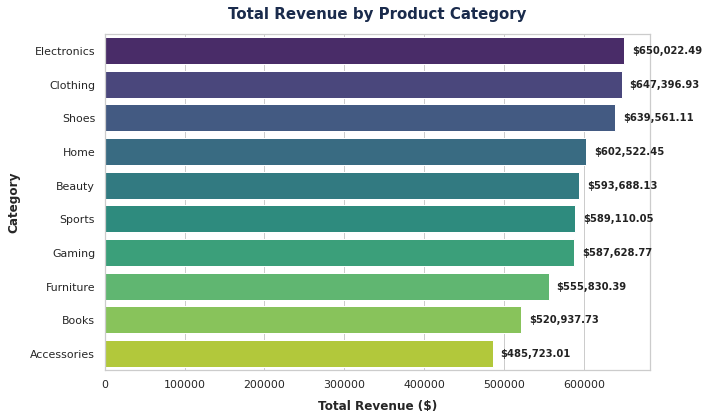

In [97]:

category_sales = spark.sql(f"""
    SELECT category, SUM(sales_amount) AS total_revenue
    FROM {HIVE_DB}.fact_sales
    GROUP BY category
    ORDER BY total_revenue DESC
""").toPandas()

plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

ax = sns.barplot(
    x="total_revenue", 
    y="category", 
    data=category_sales, 
    hue="category",      
    palette="viridis",   
    legend=False
)

plt.title("Total Revenue by Product Category", fontsize=15, fontweight='bold', pad=15, color='#1A2B4C')
plt.xlabel("Total Revenue ($)", fontsize=12, fontweight='bold', labelpad=10)
plt.ylabel("Category", fontsize=12, fontweight='bold', labelpad=10)

for p in ax.patches:
    width = p.get_width()
    ax.annotate(
        f"${width:,.2f}",
        (width, p.get_y() + p.get_height() / 2.),
        ha='left', va='center',
        xytext=(8, 0),
        textcoords='offset points',
        fontsize=10, fontweight='bold', color='#222222'
    )

plt.tight_layout()
plt.show()

In [98]:
spark.stop()